# Task 4.1 — K-Means Clustering

In [1]:
import pandas as pd, numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('clean_dataset.csv')
numeric_cols = df.select_dtypes(include=[np.number]).columns

# K-Means needs scaled data - distances matter
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])

# Fit K-Means with an initial guess of 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters
print(df['cluster'].value_counts())
print(f'\nInertia (within-cluster sum of squares): {kmeans.inertia_:.2f}')

cluster
0    280
1     45
2     35
Name: count, dtype: int64

Inertia (within-cluster sum of squares): 4767.04


# Task 4.2 — Choosing K (Elbow Method & Silhouette Score)

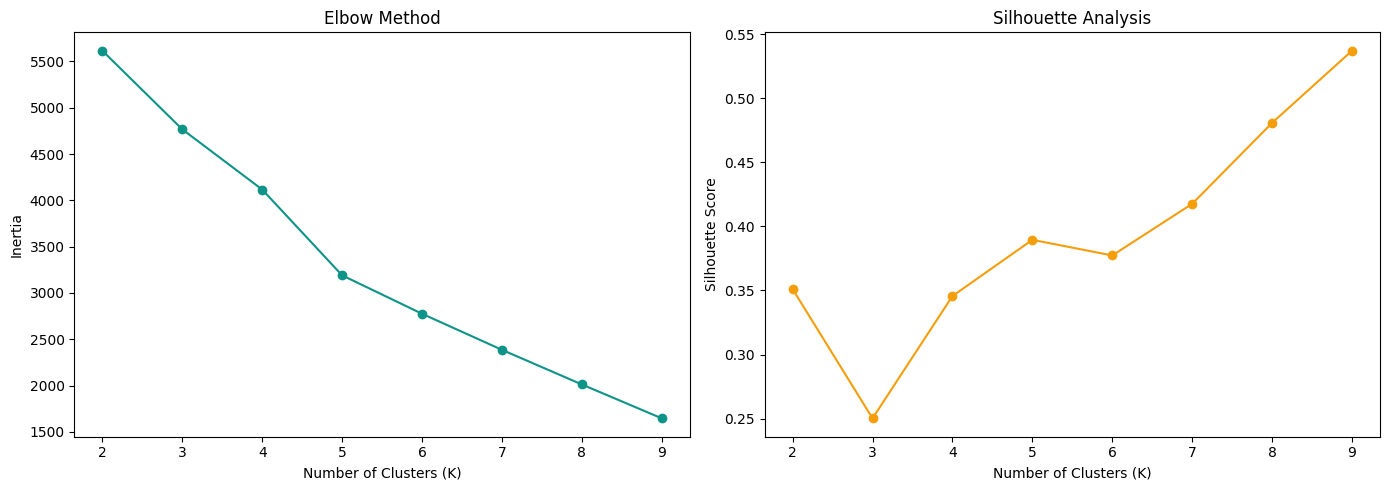

Silhouette scores: {2: 0.351, 3: 0.25, 4: 0.346, 5: 0.39, 6: 0.377, 7: 0.418, 8: 0.481, 9: 0.537}


In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(k_range, inertias, marker='o', color='#0D9488')
ax1.set_xlabel('Number of Clusters (K)'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(k_range, silhouette_scores, marker='o', color='#F59E0B')
ax2.set_xlabel('Number of Clusters (K)'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')

plt.tight_layout()
plt.savefig('kmeans_k_selection.png', dpi=150)
plt.show()

print(f'Silhouette scores: {dict(zip(k_range, [round(s,3) for s in silhouette_scores]))}')

# Task 4.3 — PCA (Dimensionality Reduction)

Explained variance ratio: [0.18398819 0.15177918]
Total variance explained by 2 components: 33.6%


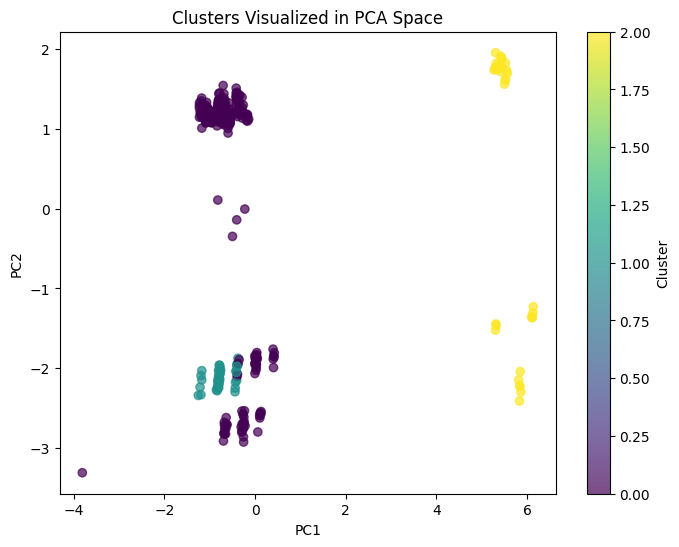

Components needed for 90% variance: 10


In [3]:
from sklearn.decomposition import PCA

# Reduce to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}')

# Visualize clusters (K=3 from Task 4.1) in 2D PCA space
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Clusters Visualized in PCA Space')
plt.colorbar(scatter, label='Cluster')
plt.savefig('pca_clusters.png', dpi=150)
plt.show()

# How many components needed for 90% variance?
pca_full = PCA().fit(X_scaled)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = np.argmax(cumsum >= 0.9) + 1
print(f'Components needed for 90% variance: {n_components_90}')

# Task 4.4 — Hierarchical Clustering

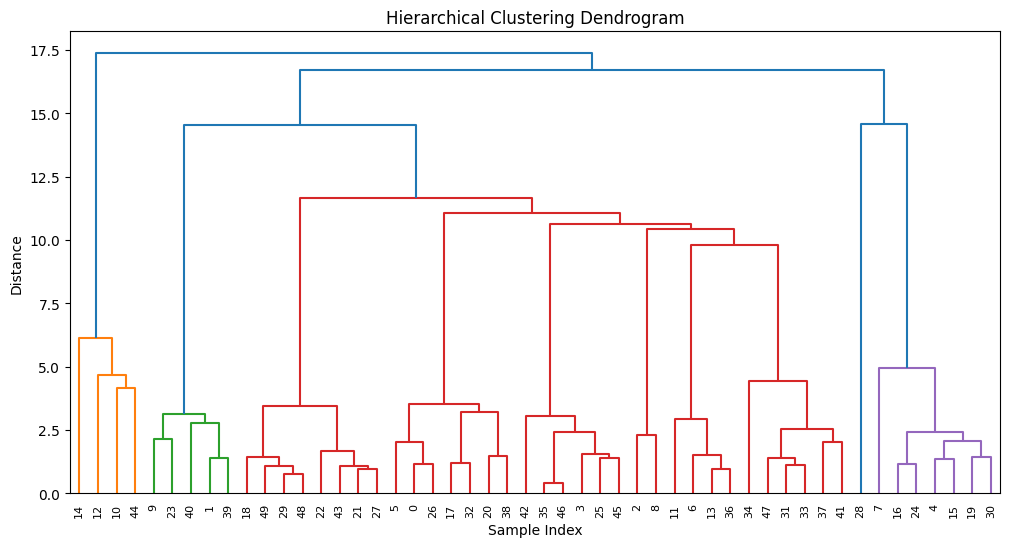

2    207
0    118
1     35
Name: count, dtype: int64

K-Means vs Hierarchical crosstab:
Agglomerative   0   1    2
KMeans                    
0              73   0  207
1              45   0    0
2               0  35    0


In [4]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Build a dendrogram (sample for readability)
linked = linkage(X_scaled[:50], method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index'); plt.ylabel('Distance')
plt.savefig('dendrogram.png', dpi=150)
plt.show()

# Fit Agglomerative Clustering with the chosen K (3)
agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X_scaled)
print(pd.Series(agg_labels).value_counts())

# Compare cluster assignments to K-Means results
print('\nK-Means vs Hierarchical crosstab:')
print(pd.crosstab(clusters, agg_labels, rownames=['KMeans'], colnames=['Agglomerative']))